# Diabetes Dataset Analysis: 130 US Hospitals (1999-2008)

## Introduction
This project aims to analyze a comprehensive dataset containing diabetes-related information from 130 US hospitals over a period of 10 years (1999-2008). The dataset includes various attributes related to patient demographics, medical conditions, treatments, and outcomes. Our goal is to uncover insights and trends that can help improve diabetes care and management.

## Dataset Description
The dataset, `diabetes+130-us+hospitals+for+years+1999-2008.zip`, contains data on diabetes patients from 130 hospitals in the United States. It includes the following key attributes:

- **Patient ID**: Unique identifier for each patient
- **Admission Type**: Type of hospital admission (e.g., emergency, urgent, elective)
- **Diagnosis**: Primary and secondary diagnoses
- **Treatment**: Medications and procedures administered
- **Outcome**: Patient outcomes (e.g., discharge status, readmission)
- **Demographics**: Age, gender, race, etc.
- **Hospital Information**: Hospital ID, location, etc.

The dataset comprises over 100,000 records, providing a rich source of information for analysis.

## Objectives
The primary objectives of this analysis are:
1. To identify trends and patterns in diabetes treatment and outcomes.
2. To analyze the impact of demographic factors on diabetes management.
3. To evaluate the effectiveness of different treatment protocols.
4. To identify potential areas for improvement in diabetes care.

## Data Loading and Initial Exploration

This section aims to extract the source data zip file and explore the csv files provided. We will use the `DataIngestorFactory` class from the `src.ingest_data` module to perform data ingestion and initial data exploration.

### Define Constants and Utility Functions

In [1]:
# Import Libraries and Modules
import os
import json
import logging
from src.ingest_data import DataIngestorFactory

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Constants
FILE_PATH = "data/diabetes+130-us+hospitals+for+years+1999-2008.zip"

def get_file_extension(file_path: str) -> str:
    """
    Returns the file extension for the given file path.
    
    Args:
        file_path (str): The path to the file.
    
    Returns:
        str: The file extension.
    """
    return os.path.splitext(file_path)[1]

def ingest_data(file_path: str) -> dict:
    """
    Ingests data from the specified file and returns metadata.
    
    Args:
        file_path (str): The path to the file to be ingested.
    
    Returns:
        dict: Metadata about the ingested data.
    """
    try:
        file_extension = get_file_extension(file_path)
        data_ingestor = DataIngestorFactory.get_data_ingestor(file_extension)
        metadata = data_ingestor.ingest(file_path)
        return metadata
    except Exception as e:
        logging.error(f"Error ingesting data: {e}")
        return None

### Data Ingestion and getting Metadata

In [19]:
# Ingest the data and get metadata
metadata = ingest_data(FILE_PATH)

# Check if metadata was successfully retrieved
if metadata:
    logging.info("Data ingestion successful. Metadata:")
    print(json.dumps(metadata, indent=4))
else:
    logging.error("Data ingestion failed.")

2025-05-03 15:28:55,796 - INFO - Data ingestion successful. Metadata:


[
    {
        "file_name": "diabetic_data.csv",
        "file_type": ".csv",
        "file_path": "c:/Users/u1109539/Downloads/CC_Project/diabetes-readmission-predictor/extracted_data/diabetic_data.csv",
        "num_rows": 101766,
        "num_columns": 50
    },
    {
        "file_name": "IDS_mapping.csv",
        "file_type": ".csv",
        "file_path": "c:/Users/u1109539/Downloads/CC_Project/diabetes-readmission-predictor/extracted_data/IDS_mapping.csv",
        "num_rows": 67,
        "num_columns": 2
    }
]


### Initial data Exploration

In [20]:
import pandas as pd

# display all columns when printing the DataFrame
pd.set_option('display.max_columns', None)

In [21]:
from IPython.display import display, Markdown

# Example: Display the first few rows of each CSV file in the dataset

# Check if metadata was successfully retrieved
if metadata:
    for file_info in metadata:
        if file_info['file_type'] == '.csv':
            csv_file_path = file_info['file_path']
            df = pd.read_csv(csv_file_path)
            display(Markdown(f"#### First few rows of `{file_info['file_name']}`:"))
            display(df.head())
else:
    logging.error("No CSV files found in metadata.")

#### First few rows of `diabetic_data.csv`:

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### First few rows of `IDS_mapping.csv`:

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


### Next Steps
In this notebook, we have ingested the diabetes dataset and performed some initial exploration. Our next steps will include:

1. Detailed analysis of patient demographics and their impact on treatment outcomes.
2. Evaluation of different treatment protocols and their effectiveness.
3. Identification of trends and patterns in hospital admissions and readmissions.

Stay tuned for more insights as we dive deeper into the data!

## Diabetes Dataset Analysis: Basic Data Inspection

This section aims to load and inspect the diabetes dataset using basic inspection strategies.

In [22]:
import io
import numpy as np
from typing import List, Optional

# Function to load data
def load_data(file_path: str, header: Optional[int] = 'infer') -> Optional[pd.DataFrame]:
    """
    Loads data from a CSV file into a pandas DataFrame.

    Args:
        file_path (str): The path to the CSV file.
        header (Optional[int]): Row number(s) to use as the column names, and the start of the data. Default is 'infer'.

    Returns:
        Optional[pd.DataFrame]: The loaded DataFrame or None if loading fails.
    """
    try:
        df = pd.read_csv(file_path, header=header)
        logging.info(f"Data loaded successfully from {file_path}")
        return df
    except Exception as e:
        logging.error(f"Error loading data from {file_path}: {e}")
        return None

# Function to display data types and non-null counts
def display_data_types(df: pd.DataFrame) -> None:
    """
    Displays data types and non-null counts of the DataFrame.
    
    Args:
        df (pd.DataFrame): The DataFrame to display info for.
    """
    buffer = io.StringIO()
    df.info(buf=buffer)
    info_str = buffer.getvalue()
    display(Markdown(f"### Data Types and Non-null Counts:\n```\n{info_str}\n```"))

# Function to display summary statistics
def display_summary_statistics(df: pd.DataFrame) -> None:
    """
    Displays summary statistics of the DataFrame.
    
    Args:
        df (pd.DataFrame): The DataFrame to display statistics for.
    """
    display(Markdown("### Summary Statistics (Numerical Features):"))
    display(df.describe())
    display(Markdown("### Summary Statistics (Categorical Features):"))
    display(df.describe(include=['object']))

# Assuming metadata is already available from the previous steps
CSV_FILE_PATH: str = metadata[0]['file_path']

# Load the diabetic_data.csv into a pandas dataframe
df_diabetes: Optional[pd.DataFrame] = load_data(CSV_FILE_PATH)

# Replace None values to NaN
if df_diabetes is not None:
    df_diabetes = df_diabetes.replace({'None': np.nan})

# Inspect the data if it was loaded successfully
if df_diabetes is not None:
    display_data_types(df_diabetes)
    display_summary_statistics(df_diabetes)

2025-05-03 15:28:56,822 - INFO - Data loaded successfully from c:/Users/u1109539/Downloads/CC_Project/diabetes-readmission-predictor/extracted_data/diabetic_data.csv


### Data Types and Non-null Counts:
```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_medications           101766 non-null  int64 
 15  number_outpatient         101766 non-null  int64 
 16  number_emergency          101766 non-null  int64 
 17  number_inpatient          101766 non-null  int64 
 18  diag_1                    101766 non-null  object
 19  diag_2                    101766 non-null  object
 20  diag_3                    101766 non-null  object
 21  number_diagnoses          101766 non-null  int64 
 22  max_glu_serum             5346 non-null    object
 23  A1Cresult                 17018 non-null   object
 24  metformin                 101766 non-null  object
 25  repaglinide               101766 non-null  object
 26  nateglinide               101766 non-null  object
 27  chlorpropamide            101766 non-null  object
 28  glimepiride               101766 non-null  object
 29  acetohexamide             101766 non-null  object
 30  glipizide                 101766 non-null  object
 31  glyburide                 101766 non-null  object
 32  tolbutamide               101766 non-null  object
 33  pioglitazone              101766 non-null  object
 34  rosiglitazone             101766 non-null  object
 35  acarbose                  101766 non-null  object
 36  miglitol                  101766 non-null  object
 37  troglitazone              101766 non-null  object
 38  tolazamide                101766 non-null  object
 39  examide                   101766 non-null  object
 40  citoglipton               101766 non-null  object
 41  insulin                   101766 non-null  object
 42  glyburide-metformin       101766 non-null  object
 43  glipizide-metformin       101766 non-null  object
 44  glimepiride-pioglitazone  101766 non-null  object
 45  metformin-rosiglitazone   101766 non-null  object
 46  metformin-pioglitazone    101766 non-null  object
 47  change                    101766 non-null  object
 48  diabetesMed               101766 non-null  object
 49  readmitted                101766 non-null  object
dtypes: int64(13), object(37)
memory usage: 38.8+ MB

```

### Summary Statistics (Numerical Features):

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### Summary Statistics (Categorical Features):

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,17018,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,3,4,4,4,4,4,2,4,4,2,4,4,4,4,2,3,1,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,>8,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,8216,81778,100227,101063,101680,96575,101765,89080,91116,101743,94438,95401,101458,101728,101763,101727,101766,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


## Check for missing values

From the "Data Types and Non-null Counts" information above, max_glu_serum and A1Cresult columns has missing values. Lets calculate what percent of values are missing.

In [23]:
def summarize_null_values(columns: List[str], df: pd.DataFrame) -> pd.DataFrame:
    """
    Function to summarize null value details for multiple columns in a DataFrame.

    Parameters:
    columns (List[str]): List of column names to check for null values.
    df (pd.DataFrame): DataFrame to check for null values.

    Returns:
    pd.DataFrame: DataFrame containing null value counts and percentages.
    """
    summary = {
        'Column': [],
        'Null Count': [],
        'Null Percentage': []
    }
    
    for colname in columns:
        colname_null = df[colname].isnull().sum()
        colname_percentage_null = round((colname_null / df.shape[0]) * 100, 2)
        summary['Column'].append(colname)
        summary['Null Count'].append(colname_null)
        summary['Null Percentage'].append(colname_percentage_null)
    
    return pd.DataFrame(summary)

In [24]:
# Columns to check for null values
columns_to_check = ['max_glu_serum', 'A1Cresult']

# Apply the "summarize_null_values" function to the specified columns
null_summary = summarize_null_values(columns_to_check, df_diabetes)
display(null_summary)

,Column,Null Count,Null Percentage
0,max_glu_serum,96420,94.75
1,A1Cresult,84748,83.28


max_glu_serum column has 94.75 % of values are missing and hence we can drop the column. OR if it is clinically important feature, we should check with SME if we can impute with mode i.e., "Norm".

A1Cresult column has 83.28 % of values are missing and hence we can drop the column. OR if it is a clinically important feature, we should check with SME if we can impute with mode i.e., ">8".

## Retrieving descriptions of the IDs mapped from IDS_mapping.csv

In [25]:
# Load the ID mapping file
CSV_FILE_PATH = metadata[1]['file_path']

# Load the IDS_mapping.csv into a pandas dataframe
id_map = load_data(CSV_FILE_PATH, header=None)

# Function to extract and clean ID mapping data
def extract_and_clean_id_mapping(id_map: pd.DataFrame, id_name: str, num_rows: int, new_col_name: str) -> pd.DataFrame:
    """
    Extract and clean ID mapping data from the given DataFrame.

    Parameters:
    id_map (pd.DataFrame): DataFrame containing the ID mappings.
    id_name (str): The name of the ID to extract.
    num_rows (int): The number of rows to extract for the ID.
    new_col_name (str): The new name for the description column.

    Returns:
    pd.DataFrame: Cleaned DataFrame for the specified ID.
    """
    start_idx = id_map.loc[id_map[0] == id_name].index[0]
    df_id = id_map.loc[start_idx:start_idx + num_rows].copy()
    df_id.columns = df_id.iloc[0]
    df_id = df_id[1:].reset_index(drop=True)
    df_id.columns.name = None
    df_id = df_id.rename(columns={df_id.columns[1]: new_col_name})
    df_id[id_name] = df_id.iloc[:, 0].astype(int)
    return df_id

# Extract and clean ID mappings
df_admission_type_id = extract_and_clean_id_mapping(id_map, 'admission_type_id', 8, 'admission_type')
df_discharge_disposition_id = extract_and_clean_id_mapping(id_map, 'discharge_disposition_id', 30, 'discharge_disposition')
df_admission_source_id = extract_and_clean_id_mapping(id_map, 'admission_source_id', 27, 'admission_source')

# Merge with the main DataFrame
df_diabetes = df_diabetes.merge(df_admission_type_id, how='left', on='admission_type_id')
df_diabetes = df_diabetes.merge(df_discharge_disposition_id, how='left', on='discharge_disposition_id')
df_diabetes = df_diabetes.merge(df_admission_source_id, how='left', on='admission_source_id')

# Drop the original ID columns
df_diabetes.drop(['admission_type_id', 'discharge_disposition_id', 'admission_source_id'], axis=1, inplace=True)

# Display the final DataFrame
display(df_diabetes)

2025-05-03 15:28:57,784 - INFO - Data loaded successfully from c:/Users/u1109539/Downloads/CC_Project/diabetes-readmission-predictor/extracted_data/IDS_mapping.csv


,encounter_id,patient_nbr,race,gender,age,weight,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source
0,2278392,8222157,Caucasian,Female,[0-10),?,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,NaN,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),?,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),?,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room
3,500364,82442376,Caucasian,Male,[30-40),?,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
4,16680,42519267,Caucasian,Male,[40-50),?,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30,Emergency,Discharged/transferred to SNF,Emergency Room
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO,Emergency,Discharged/transferred to ICF,Transfer from a Skilled Nursing Facility (SNF)
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO,Emergency,Discharged to home,Emergency Room
101764,443857166,31693671,Caucasian,Female,[80-90),?,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,Urgent,Discharged/transferred to SNF,Emergency Room


In [26]:
# Columns to check for null values
columns_to_check = ['admission_source', 'admission_type', 'discharge_disposition']

# Apply the "summarize_null_values" function to the specified columns
null_summary = summarize_null_values(columns_to_check, df_diabetes)
display(null_summary)

,Column,Null Count,Null Percentage
0,admission_source,6781,6.66
1,admission_type,5291,5.20
2,discharge_disposition,3691,3.63


Since admission_source column has 6781 i.e. 6.66 % null values, we can impute it with "Not Available", considering not to bilindly impute with most frequent value, as it may false interpret the data. Advise needed on this.

Same decision for admission_type column.

Same decision for discharge_disposition column, but mapping to "Not Mapped".

## Data Pre-processing

In [27]:
from data.preprocessing import Preprocessor

In [28]:
# Initialize Preprocessor with the loaded data
preprocessor = Preprocessor(df_diabetes)
    
# Define mappings and columns to drop
icd9_chapter_mapping = {
    '001-139': '001-139', '140-239': '140-239', '240-279': '240-279', '280-289': '280-289',
    '290-319': '290-319', '320-389': '320-389', '390-459': '390-459', '460-519': '460-519',
    '520-579': '520-579', '580-629': '580-629', '630-679': '630-679', '680-709': '680-709',
    '710-739': '710-739', '740-759': '740-759', '760-779': '760-779', '780-799': '780-799',
    '800-999': '800-999', 'V01-V91': 'V01-V91', 'E000-E999': 'E000-E999'
}
grouping = {
    'Primary Care': ['InternalMedicine', 'Family/GeneralPractice', 'Pediatrics', 'ObstetricsandGynecology'],
    'Surgery': ['Surgery-General', 'Orthopedics', 'Surgery-Cardiovascular/Thoracic'],
    'Specialized Medicine': ['Cardiology', 'Gastroenterology', 'Nephrology', 'Psychiatry'],
    'Other Services': ['Anesthesiology', 'Dentistry', 'Surgeon']
}
admission_sources = {
    "Referrals": ["Clinic Referral", "Physician Referral", "HMO Referral"],
    "Transfers": ["Transfer from a hospital", "Transfer from a Skilled Nursing Facility (SNF)", 
                    "Transfer from another health care facility", "Transfer from critial access hospital", 
                    "Transfer from hospital inpt/same fac reslt in a sep claim", "Transfer from Ambulatory Surgery Center"],
    "Emergency and Law Enforcement": ["Emergency Room", "Court/Law Enforcement"],
    "Special Circumstances": ["Extramural Birth", "Normal Delivery", "Sick Baby"],
    "Uncategorized/Other": ["Not Mapped", "Not Available", "nan"]
}
discharge_categories = {
    "Home Discharge": ["Discharged to home", "Discharged/transferred to home with home health service", 
                        "Discharged/transferred to home under care of Home IV provider", "Hospice / home"],
    "Specialized Care Facilities": ["Discharged/transferred to SNF", "Discharged/transferred to ICF", 
                                    "Discharged/transferred to a long term care hospital.", 
                                    "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.", 
                                    "Discharged/transferred to a federal health care facility."],
    "Hospitals & Rehab": ["Discharged/transferred to another short term hospital", 
                            "Discharged/transferred to another type of inpatient care institution", 
                            "Discharged/transferred to another rehab fac including rehab units of a hospital .", 
                            "Neonate discharged to another hospital for neonatal aftercare", 
                            "Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital"],
    "Within Institution": ["Discharged/transferred within this institution to Medicare approved swing bed", 
                            "Still patient or expected to return for outpatient services", 
                            "Discharged/transferred/referred to this institution for outpatient services"],
    "Between Institutions": ["Discharged/transferred/referred another institution for outpatient services"],
    "Hospice Care": ["Hospice / medical facility", "Expired in a medical facility. Medicaid only, hospice.", 
                        "Expired at home. Medicaid only, hospice."],
    "Expired": ["Expired"],
    "Admissions & AMA": ["Admitted as an inpatient to this hospital", "Left AMA (Against Medical Advice)"],
    "Uncategorized": ["Not Mapped", "nan (Not Available/Not Applicable)"]
}
columns_with_high_concentration = ['encounter_id', 'patient_nbr']

# Preprocess the data
df_cleaned = preprocessor.preprocess(icd9_chapter_mapping, grouping, admission_sources, discharge_categories, columns_with_high_concentration)
    
# Print the first few rows of the cleaned data to verify
display(df_cleaned.head())

,race,gender,age,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source
1,Caucasian,Female,2,3,MC,Primary Care,59,0,18,0,0,0,240-279,240-279,240-279,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,Emergency,Home Discharge,Emergency and Law Enforcement
2,AfricanAmerican,Female,3,2,MC,Primary Care,11,5,13,2,0,1,630-679,240-279,V01-V91,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,Emergency,Home Discharge,Emergency and Law Enforcement
3,Caucasian,Male,4,2,MC,Primary Care,44,1,16,0,0,0,001-139,240-279,390-459,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,Emergency,Home Discharge,Emergency and Law Enforcement
4,Caucasian,Male,5,1,MC,Primary Care,51,0,8,0,0,0,140-239,140-239,240-279,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,Emergency,Home Discharge,Emergency and Law Enforcement
5,Caucasian,Male,6,3,MC,Primary Care,31,6,16,0,0,0,390-459,390-459,240-279,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,>30,Urgent,Home Discharge,Referrals


## Model training and predesction

In [29]:
from models.model_trainer import ModelTrainer

In [30]:
# Initialize ModelTrainer with the cleaned data
model_trainer = ModelTrainer(df_cleaned)

In [31]:
import matplotlib.pyplot as plt
from xgboost import Booster

def feature_imp(model_name: Booster) -> None:
    """
    Plot the feature importances of a given XGBoost model.

    Parameters:
    model_name (Booster): The XGBoost model to extract feature importances from.
    """
    # 'get_booster().get_fscore()' returns a dictionary of feature importances
    feat_imp = pd.Series(model_name.get_booster().get_fscore()).sort_values(ascending=False)

    # Set the figure size to make it wider
    plt.figure(figsize=(16, 6))
    
    # Create a bar plot
    feat_imp.plot(kind='bar', title='Feature Importances')
    
    # Set the y-axis label
    plt.ylabel('Feature Importance Score')
    
    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=90)
    
    # Adjust the layout to prevent labels from overlapping
    plt.tight_layout()
    
    # Show the plot
    plt.show()

### Prediction with cleaned dataset and one-hot encoding

In [32]:
# Scenario 1: Prediction with cleaned dataset and one-hot encoding
X_train, X_test, y_train, y_test = model_trainer.prepare_data(one_hot_encode=True)
model = model_trainer.train_model(X_train, y_train, X_test, y_test)
y_pred = model_trainer.predict(model, X_test)


Model Report
Accuracy: 0.6439487650133674
Confusion Matrix:
[[6245 5361]
 [3562 9893]]
Precision: 0.6431044925574831
Recall: 0.6439487650133674
F1 Score: 0.6401477209234472


### Prediction with dataset (not cleaned) without manually handling missing values

In [33]:
# Scenario 2: Prediction with dataset (not cleaned) without manually handling missing values
model_trainer_raw = ModelTrainer(df_diabetes)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = model_trainer_raw.prepare_data_with_missing_values()
model_raw = model_trainer_raw.train_model(X_train_raw, y_train_raw, X_test_raw, y_test_raw)
y_pred_raw = model_trainer_raw.predict(model_raw, X_test_raw)


Model Report
Accuracy: 0.6476692083955664
Confusion Matrix:
[[ 6373  5353]
 [ 3611 10105]]
Precision: 0.6466157712200967
Recall: 0.6476692083955664
F1 Score: 0.6440527407568011


### Prediction without one-hot encoding - dataset not cleaned

In [34]:
# Scenario 3: Prediction without one-hot encoding - dataset not cleaned
X_train_no_ohe, X_test_no_ohe, y_train_no_ohe, y_test_no_ohe = model_trainer_raw.prepare_data_without_one_hot_encoding(cleaned=False)
model_no_ohe = model_trainer_raw.train_model(X_train_no_ohe, y_train_no_ohe, X_test_no_ohe, y_test_no_ohe, enable_categorical=True)
y_pred_no_ohe = model_trainer_raw.predict(model_no_ohe, X_test_no_ohe)


Model Report
Accuracy: 0.6339124282682179
Confusion Matrix:
[[ 5693  6033]
 [ 3281 10435]]
Precision: 0.6339919408817508
Recall: 0.6339124282682179
F1 Score: 0.6262661900050907


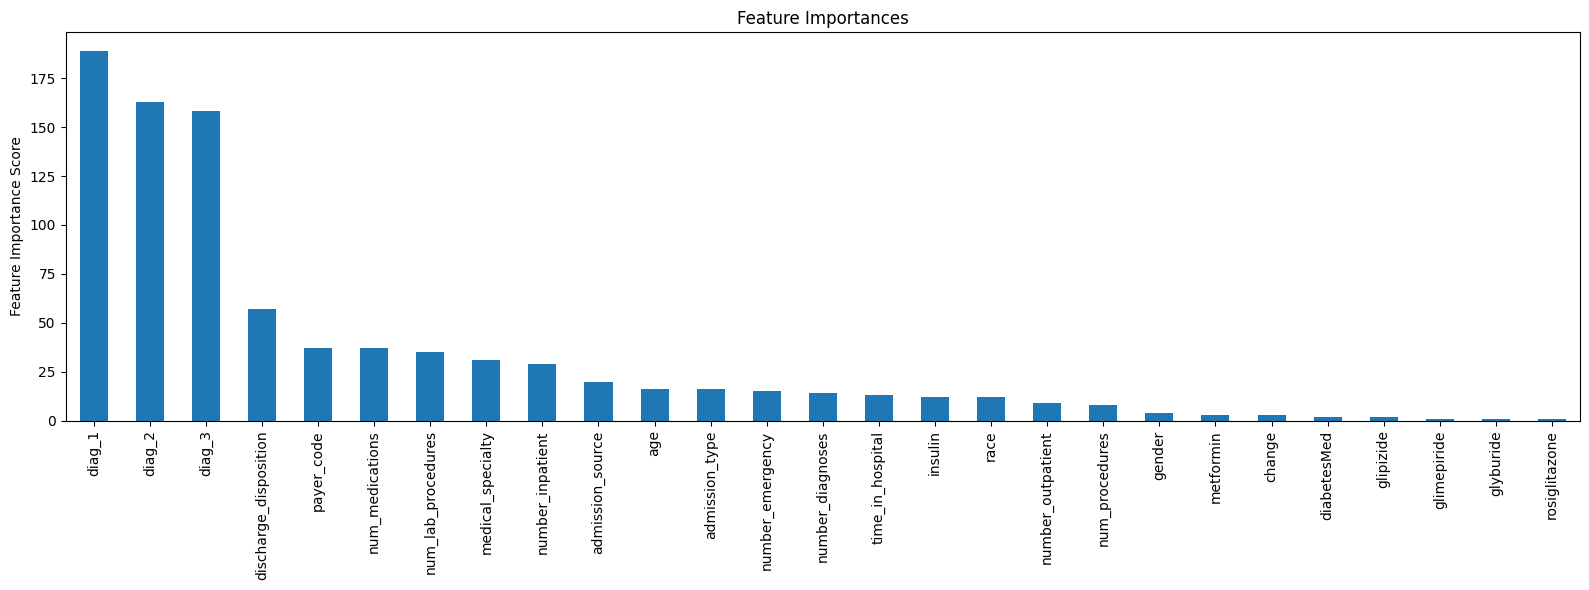

In [35]:
feature_imp(model_no_ohe)

### Prediction with cleaned dataset, but without one-hot encoding

In [36]:
# Scenario 4: Prediction with cleaned dataset, but without one-hot encoding
X_train_clean_no_ohe, X_test_clean_no_ohe, y_train_clean_no_ohe, y_test_clean_no_ohe = model_trainer.prepare_data_without_one_hot_encoding(cleaned=True)
model_clean_no_ohe = model_trainer.train_model(X_train_clean_no_ohe, y_train_clean_no_ohe, X_test_clean_no_ohe, y_test_clean_no_ohe, enable_categorical=True)
y_pred_clean_no_ohe = model_trainer.predict(model_clean_no_ohe, X_test_clean_no_ohe)


Model Report
Accuracy: 0.639719085431547
Confusion Matrix:
[[6121 5485]
 [3544 9911]]
Precision: 0.638911848739498
Recall: 0.639719085431547
F1 Score: 0.6354003437966413


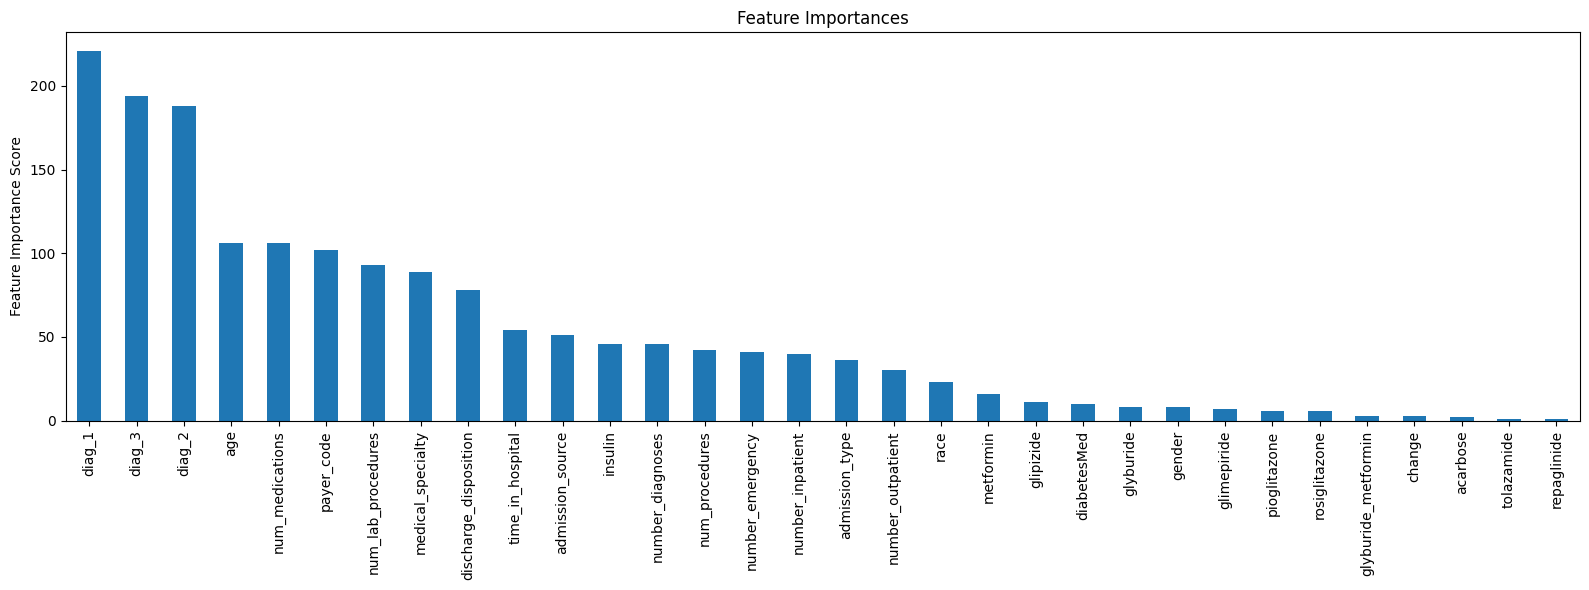

In [37]:
feature_imp(model_clean_no_ohe)

### Prediction with cleaned dataset with cross-validation

In [38]:
# Scenario 5: Prediction with cleaned dataset with cross-validation
dtrain_clean = model_trainer.prepare_data_for_cross_validation(cleaned=True)
model_trainer.train_with_cross_validation(dtrain_clean)


Model Report
Accuracy: 0.6696461527718199
Confusion Matrix:
[[26546 19877]
 [13238 40580]]
Precision: 0.6693833704329741
Recall: 0.6696461527718199
F1 Score: 0.6665217303352675


### Prediction with dataset not cleaned with cross-validation

In [39]:
# Scenario 6: Prediction with dataset not cleaned with cross-validation
dtrain_raw = model_trainer_raw.prepare_data_for_cross_validation(cleaned=False)
model_trainer_raw.train_with_cross_validation(dtrain_raw)


Model Report
Accuracy: 0.7130868856002988
Confusion Matrix:
[[30875 16027]
 [13171 41693]]
Precision: 0.7124874237580068
Recall: 0.7130868856002988
F1 Score: 0.7122211490522558


## Conclusion

After conducting cross-validation on both cleaned and uncleaned datasets, we observed the following results:

Uncleaned Dataset: The prediction model achieved the highest accuracy of 71.3%. However, this approach required significantly more computational time due to the presence of noise and inconsistencies in the data.

Cleaned Dataset: The prediction model achieved an accuracy of 66.9%. Despite the slightly lower accuracy, this approach is more efficient and optimal. The data cleaning process removed noise and inconsistencies, leading to faster computation times and more reliable results.

In conclusion, while the uncleaned dataset provided a marginally higher accuracy, the cleaned dataset with cross-validation is the optimal choice. It balances accuracy and computational efficiency, making it a more practical solution for real-world applications.